✅ Données chargées avec succès
X_train shape: (1460, 230)
y_train_log shape: (1460,)

✅ 30 features sélectionnées avec RFE:
 ['MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Utilities_NoSeWa', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'Condition2_PosA', 'RoofMatl_CompShg', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'Exterior1st_BrkComm', 'Exterior1st_ImStucc', 'Exterior2nd_Stone', 'ExterCond_Po', 'Foundation_Slab', 'Heating_GasA', 'Heating_GasW', 'Heating_OthW', 'Heating_Wall', 'HeatingQC_Po', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA', 'Functional_Maj2', 'SaleType_Con']

🌟 Top 30 features importantes selon Random Forest:
 ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea', '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'CentralAir_Y', 'OverallCond', 'LotArea', 'GarageFinish_Unf', 'YearRemodAdd', 'LotFrontage', 'Fireplaces', '2ndFlrSF', 'BsmtUnfSF', 'Id', 'OpenPorchSF', 'Gar

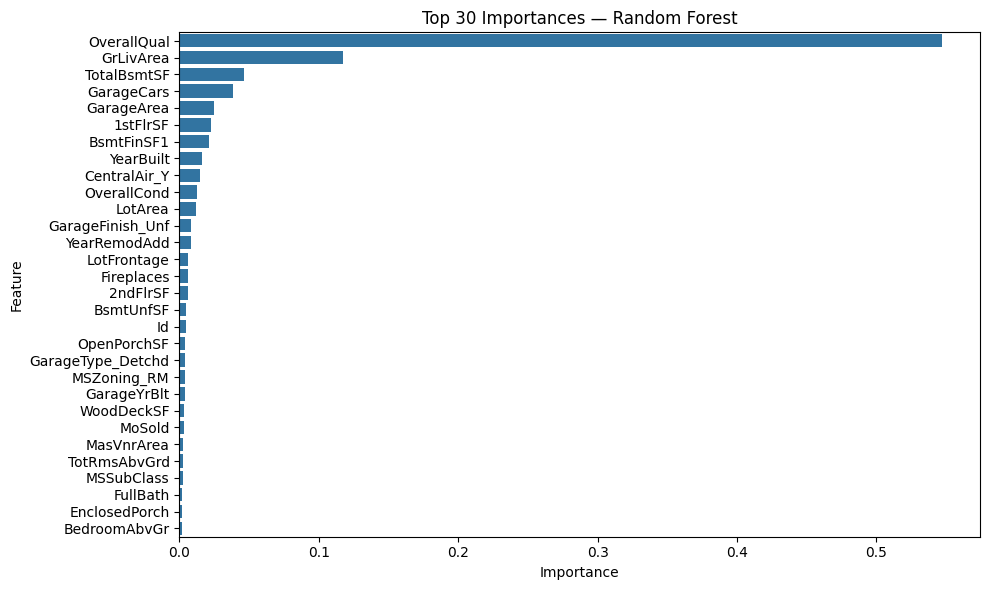

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# 🔁 1. Chargement des datasets prétraités
X_train = pd.read_csv('../Data/X_train_encoded.csv')
y_train_log = pd.read_csv('../Data/y_train_log.csv').squeeze()  # .squeeze() pour convertir en Series

print("✅ Données chargées avec succès")
print(f"X_train shape: {X_train.shape}")
print(f"y_train_log shape: {y_train_log.shape}")

# 🔍 2. Sélection de features avec RFE
model_lr = LinearRegression()
rfe = RFE(model_lr, n_features_to_select=30)
rfe.fit(X_train, y_train_log)

# Résultats RFE
rfe_support = pd.Series(rfe.support_, index=X_train.columns)
rfe_selected = rfe_support[rfe_support].index.tolist()
print(f"\n✅ {len(rfe_selected)} features sélectionnées avec RFE:\n", rfe_selected)

# 🌳 3. Importance des features avec Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train_log)

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
top_rf = importances.sort_values(ascending=False).head(30)
print(f"\n🌟 Top 30 features importantes selon Random Forest:\n", top_rf.index.tolist())

# 🔁 4. Intersection des deux méthodes
combined = list(set(rfe_selected) & set(top_rf.index))
print(f"\n🔗 {len(combined)} features communes aux deux méthodes:\n", combined)

# 📊 5. Visualisation des importances RF
plt.figure(figsize=(10, 6))
sns.barplot(x=top_rf.values, y=top_rf.index)
plt.title("Top 30 Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
